In [18]:
import sys
import os

# Always anchor relative to THIS file's location
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    #sys.path.insert(0, src_path)

import numpy as np
import torch
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from vqe import cost_function
from ml_model import VQEModel
import subprocess

src = os.path.join(project_root, "src")

scripts = ["data_generation.py", "ml_model.py"]

for script in scripts:
    path = os.path.join(src, script)
    result = subprocess.run(["python", path])
    
    if result.returncode != 0:
        print(f"{script} failed!")
        break

#!python src_path/data_generation.py
#!python ../src/ml_model.py


Final Energy: -1.8572740132249164
Running sample 1/100
Running sample 2/100
Running sample 3/100
Running sample 4/100
Running sample 5/100
Running sample 6/100
Running sample 7/100
Running sample 8/100
Running sample 9/100
Running sample 10/100
Running sample 11/100
Running sample 12/100
Running sample 13/100
Running sample 14/100
Running sample 15/100
Running sample 16/100
Running sample 17/100
Running sample 18/100
Running sample 19/100
Running sample 20/100
Running sample 21/100
Running sample 22/100
Running sample 23/100
Running sample 24/100
Running sample 25/100
Running sample 26/100
Running sample 27/100
Running sample 28/100
Running sample 29/100
Running sample 30/100
Running sample 31/100
Running sample 32/100
Running sample 33/100
Running sample 34/100
Running sample 35/100
Running sample 36/100
Running sample 37/100
Running sample 38/100
Running sample 39/100
Running sample 40/100
Running sample 41/100
Running sample 42/100
Running sample 43/100
Running sample 44/100
Running

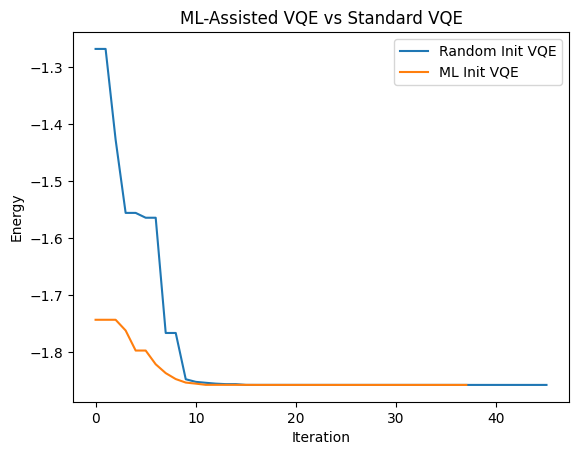

In [25]:
# -------------------------
# Load trained ML model
# -------------------------
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
MODEL_PATH = PROJECT_ROOT / "data" / "vqe_model.pth"
model = VQEModel()
model.load_state_dict(torch.load(MODEL_PATH))

#model.load_state_dict(torch.load("data/vqe_model.pth"))
model.eval()

# -------------------------
# Helper: run VQE
# -------------------------

def run_vqe(theta_init):

    energies = []

    def callback(xk):
        e = cost_function(xk)
        energies.append(e)

    result = minimize(
        cost_function,
        theta_init,
        method="COBYLA",
        callback=callback
    )

    return energies


# -------------------------
# 1. Baseline VQE
# -------------------------

theta_random = np.random.uniform(0, 2*np.pi, 4)

baseline_energies = run_vqe(theta_random)


# -------------------------
# 2. ML-assisted VQE
# -------------------------

theta_input = torch.tensor(theta_random, dtype=torch.float32)

with torch.no_grad():
    theta_ml = model(theta_input).numpy()

ml_energies = run_vqe(theta_ml)


# -------------------------
# Plot comparison
# -------------------------

plt.plot(baseline_energies, label="Random Init VQE")
plt.plot(ml_energies, label="ML Init VQE")

plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("ML-Assisted VQE vs Standard VQE")
plt.legend()

plt.show()